In [56]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
import csv
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [57]:
#General Parameters

alpha      = 0.5    # Bell curve coefficient
dropout    = 0.1   # Neuron deactivation (0 = off for small datasets)
epochs     = 800    # increased: force model had more to give
seed       = 42
patience   = 50    # increased: allow more time before early stop
batch_size = 32


In [58]:
#import Excel Data

notebook_dir = os.getcwd()
file_path = os.path.join(notebook_dir, 'Data', 'MLPartAB4.xlsx')

#read Excel with data values only
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active
headers = [ws_data.cell(1, col).value for col in range(1, ws_data.max_column + 1)]
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]

df_training = pd.DataFrame(data, columns=headers)
df_training = df_training.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True)
print(f"df_training shape: {df_training.shape}")


df_training shape: (796, 20)


In [59]:
# Verify 
# ── 8. Verify against Excel ───────────────────────────────────
print(f"\n{'='*60}")
print(f"  Verify — Python vs Excel (row 1)")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
print(f"{'-'*60}")


# ── 9. Final dataset summary ──────────────────────────────────
print(f"\n{'='*60}")
print(f"  FINAL DATASET")
print(f"{'='*60}")
print(f"  Shape   : {df_training.shape}")
print(f"  Columns : {df_training.columns.tolist()}")
print(f"\n{'='*60}")
print(f"  STATISTICS")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"{'-'*60}")
for col in df_training.columns:
    vals = df_training[col].dropna()
    if vals.dtype in [float, int]:
        print(f"{col:>15} | {vals.min():>12.4f} | "
              f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
print(f"{'='*60}")


  Verify — Python vs Excel (row 1)
         Column |        Excel |       Python |  Match
------------------------------------------------------------

  FINAL DATASET
  Shape   : (796, 20)
  Columns : ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR', 'Torque', 'P_input', 'Fbox (N)', 'width (m)', 'height (m)', 'pin_dia (m)', '|RT0|max', '|P1|max', '|B0|max', 'FOS', 'N_to', 'N_Bo', 'N_P1']

  STATISTICS
         Column |          Min |          Max |         Mean
------------------------------------------------------------
          r (m) |       0.0440 |       0.1994 |       0.1274
          e (m) |       0.0100 |       0.0500 |       0.0304
          L (m) |       0.2554 |       1.1774 |       0.5769
        Ac (m²) |       0.0001 |       0.0010 |       0.0006
        Ar (m²) |       0.0001 |       0.0010 |       0.0006
            RPM |      15.0355 |      44.9652 |      30.1682
            QRR |       1.0021 |       1.0722 |       1.0198
         Torque |       0.1301

In [60]:
# ── Target column definitions ──────────────────────────────────────────────────
input_col = ['r (m)', 'e (m)', 'L (m)', 'RPM', 'QRR','width (m)', 'height (m)', 'pin_dia (m)','FOS','Fbox (N)']
force_cols   = ['|RT0|max', '|P1|max', '|B0|max','Torque','P_input']
fatigue_cols = ['N_to', 'N_Bo', 'N_P1']   # already log10 from Excel

target_col = force_cols + fatigue_cols
n_force    = len(force_cols)    # 7
n_fatigue  = len(fatigue_cols)  # 3
n_output   = len(target_col)    # 10
n_input =len(input_col)




Yf = df_training[force_cols].copy()
Ya = df_training[fatigue_cols].copy()   # already log10 from Excel
Y  = df_training[target_col].copy()
X  = df_training[input_col].copy()


feature_cols = list(X.columns)


assert np.isfinite(Ya.values).all(), \
    f"Non-finite values in Ya — check log10 columns in Excel. " \
    f"Inf count: {np.isinf(Ya.values).sum()}"


x  = torch.tensor(X.values,  dtype=torch.float32)
yf = torch.tensor(Yf.values, dtype=torch.float32)
ya = torch.tensor(Ya.values, dtype=torch.float32)
y  = torch.tensor(Y.values,  dtype=torch.float32)
c  = torch.tensor(C.values,  dtype=torch.float32)

print(f"  Dataframe ")
print(f"\n  C  — Constants (also in X)     : {C.shape}")
print(f"       {C.columns.tolist()}")
print(f"\n  Yf — Force targets  (stage 1)  : {Yf.shape}")
print(f"       {Yf.columns.tolist()}")
print(f"\n  Ya — Fatigue targets (stage 2) : {Ya.shape}")
print(f"       {Ya.columns.tolist()}")
print(f"\n  X  — Features (incl. constants): {X.shape}")
print(f"       {X.columns.tolist()}")
print()
print(f"  x  tensor : {x.shape}   NaN: {torch.isnan(x).sum().item()}")
print(f"  yf tensor : {yf.shape}  NaN: {torch.isnan(yf).sum().item()}")
print(f"  ya tensor : {ya.shape}  NaN: {torch.isnan(ya).sum().item()}")
print(f"  c  tensor : {c.shape}   NaN: {torch.isnan(c).sum().item()}")
print(f"\n  ya range  : min={ya.min().item():.3f}  max={ya.max().item():.3f}")

  Dataframe 

  C  — Constants (also in X)     : (796, 0)
       []

  Yf — Force targets  (stage 1)  : (796, 5)
       ['|RT0|max', '|P1|max', '|B0|max', 'Torque', 'P_input']

  Ya — Fatigue targets (stage 2) : (796, 3)
       ['N_to', 'N_Bo', 'N_P1']

  X  — Features (incl. constants): (796, 10)
       ['r (m)', 'e (m)', 'L (m)', 'RPM', 'QRR', 'width (m)', 'height (m)', 'pin_dia (m)', 'FOS', 'Fbox (N)']

  x  tensor : torch.Size([796, 10])   NaN: 0
  yf tensor : torch.Size([796, 5])  NaN: 0
  ya tensor : torch.Size([796, 3])  NaN: 0
  c  tensor : torch.Size([796, 0])   NaN: 0

  ya range  : min=6.886  max=49.405


  |r| = 1.000  :  width (m)  ↔  height (m)


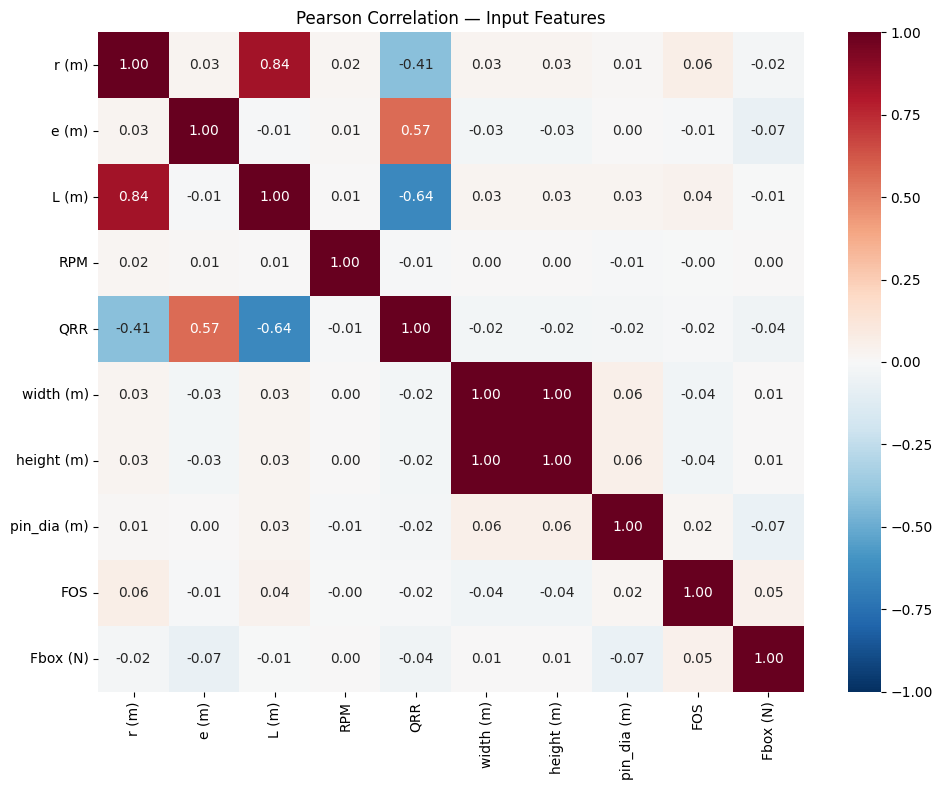

In [61]:
import seaborn as sns

corr = df_training[input_col].corr(method='pearson')

# Flag high-correlation pairs
threshold = 0.85
for i in range(len(input_col)):
    for j in range(i+1, len(input_col)):
        r = corr.iloc[i, j]
        if abs(r) > threshold:
            print(f"  |r| = {abs(r):.3f}  :  {input_col[i]}  ↔  {input_col[j]}")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1)
plt.title('Pearson Correlation — Input Features')
plt.tight_layout()
plt.show()

In [ ]:
#Parameters

num_workers=0   # cpu (AI Recommended)

class Training(Dataset):

    def __init__(self, x_mix, yf_mix,ya_mix):
        assert x_mix.shape[0] == yf_mix.shape[0]==ya_mix.shape[0]
        self.x_mix  = x_mix
        self.yf_mix  = yf_mix
        self.ya_mix=ya_mix

    def __len__(self):return self.x_mix.shape[0]
    def __getitem__(self, idx):
        return (self.x_mix[idx],self.yf_mix[idx],self.ya_mix[idx])

class Validation(Dataset):
    def __init__(self,x,yf,ya,c):
        assert x.shape[0] == yf.shape[0] ==ya.shape[0]== c.shape[0]
        self.x = x
        self.yf=yf
        self.ya=ya
        self.c = c

    def __len__(self):return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.yf[idx],self.ya[idx], self.c[idx]

def get_dataloaders(train_ds,val_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:
    g = torch.Generator().manual_seed(seed) #shuffle generator

    train_loader = DataLoader(
        train_ds,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        generator   = g, #shuffle
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = batch_size,
        shuffle     = False,
        drop_last   = False,
        num_workers = num_workers,
    )
    return train_loader, val_loader


class FatigueLoss(nn.Module):
    def __init__(self, delta=0.5, overpredict_weight=1.5):
        super().__init__()
        self.delta = delta
        self.w_over = overpredict_weight

    def forward(self, pred, target):
        error = pred - target
        abs_error = error.abs()

        # Huber: quadratic below delta, linear above
        quadratic = 0.5 * error ** 2
        linear    = self.delta * (abs_error - 0.5 * self.delta)
        huber     = torch.where(abs_error <= self.delta, quadratic, linear)

        # Asymmetric weight: pred > target = overprediction = dangerous
        weight = torch.where(error > 0,
                             self.w_over,
                             1.0)

        return (weight * huber).mean()


In [63]:
from sklearn.model_selection import train_test_split

def split_data(x, yf, ya, c, seed, train_frac=0.70, val_frac=0.15):
    n = len(x)
    test_frac = 1.0 - train_frac - val_frac

    # Stratify on FOS if available, otherwise bin primary force output
    fos_col_idx = None
    if 'FOS' in feature_cols:
        fos_col_idx = feature_cols.index('FOS')

    if fos_col_idx is not None:
        strata = x[:, fos_col_idx].numpy()
    else:
        # Bin the first force target into quantiles
        vals = yf[:, 0].numpy()
        strata = np.digitize(vals, np.percentile(vals, np.linspace(0, 100, 6)[1:-1]))

    indices = np.arange(n)

    # Split 1: train vs (val+test)
    train_idx, valtest_idx = train_test_split(
        indices, test_size=val_frac + test_frac,
        stratify=strata, random_state=seed)

    # Split 2: val vs test
    relative_test = test_frac / (val_frac + test_frac)
    valtest_strata = strata[valtest_idx]
    val_idx, test_idx = train_test_split(
        valtest_idx, test_size=relative_test,
        stratify=valtest_strata, random_state=seed)

    return (torch.tensor(train_idx), torch.tensor(val_idx),
            torch.tensor(test_idx))

def mixup(x, yf,ya, alpha=alpha, seed=seed):
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)
    idx_p = torch.randperm(N)

    x_mix = lam_t*x+(1-lam_t)*x[idx_p]
    yf_mix = lam_t*yf+(1-lam_t)*yf[idx_p]
    ya_mix = lam_t*ya+(1-lam_t)*ya[idx_p]

    return x_mix, yf_mix, ya_mix

train_idx, val_idx, test_idx = split_data(x, yf, ya, c, seed)

In [64]:
class Sohoite_Force(nn.Module):
    def __init__(self, input_dim, n_force=n_force, dropout=dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(n_force)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1)
        return torch.cat([head(h2) for head in self.heads], dim=1)
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Relu: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Relu: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid\n'

In [65]:
class Sohoite_Fatigue(nn.Module):
    def __init__(self, input_dim, n_force=n_force, n_fatigue=n_fatigue, dropout=dropout):
        super().__init__()
        combined_dim = input_dim + n_force

        self.hidden1 = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Linear(combined_dim, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_fatigue)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, Force_P):
        combined = torch.cat([x, Force_P], dim=1)
        h1 = self.hidden1(combined)
        h2 = self.hidden2(h1)
        h2 = h2 + self.skip(combined)
        return torch.cat([head(h2) for head in self.heads], dim=1)









In [ ]:
# Functions

def train_force_epoch(force_model, loader, optimizer, device,
                      x_mean, x_std, yf_mean, yf_std):
    force_model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0

    for x_mix, yf_mix, _ in loader:
        x_mix  = x_mix.to(device)
        yf_mix = yf_mix.to(device)

        optimizer.zero_grad()
        pred_forces = force_model(x_mix)
        loss = criterion(pred_forces, yf_mix)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)


def train_fatigue_epoch(force_model, fatigue_model, loader, optimizer, device,
                        x_mean, x_std, yf_mean, yf_std, ya_mean, ya_std):
    force_model.eval()
    fatigue_model.train()
    criterion  = FatigueLoss(delta=0.5, overpredict_weight=1.5)  # ← here
    total_loss = 0.0

    for x_mix, _, ya_mix in loader:
        x_mix  = x_mix.to(device)
        ya_mix = ya_mix.to(device)

        optimizer.zero_grad()
        with torch.no_grad():
            pred_forces = force_model(x_mix)

        pred_fatigue = fatigue_model(x_mix, pred_forces)
        loss = criterion(pred_fatigue, ya_mix)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fatigue_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_force(force_model, loader, device):
    force_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pf, all_tf = [], []

    for x_batch, yf_batch, ya_batch, _ in loader:   # Validation yields 4 items
        x_batch  = x_batch.to(device)
        yf_batch = yf_batch.to(device)

        pred_f = force_model(x_batch)
        total_loss += criterion(pred_f, yf_batch).item() * len(x_batch)
        all_pf.append(pred_f.cpu())
        all_tf.append(yf_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pf), torch.cat(all_tf),
    )


@torch.no_grad()
def evaluate_fatigue(force_model, fatigue_model, loader, device):
    force_model.eval()
    fatigue_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pa, all_ta = [], []

    for x_batch, yf_batch, ya_batch, _ in loader:   # Validation yields 4 items
        x_batch  = x_batch.to(device)
        ya_batch = ya_batch.to(device)

        pred_f  = force_model(x_batch)               # cascade
        pred_fa = fatigue_model(x_batch, pred_f)
        total_loss += criterion(pred_fa, ya_batch).item() * len(x_batch)
        all_pa.append(pred_fa.cpu())
        all_ta.append(ya_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pa), torch.cat(all_ta),
    )


def tester_force(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    y_pred_log = y_pred_norm * y_std + y_mean
    y_true_log = y_true_norm * y_std + y_mean
    y_pred = torch.expm1(y_pred_log).numpy()    # inverse of log1p
    y_true = torch.expm1(y_true_log).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae

def tester_fatigue(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    """Fatigue is already log10 — just undo z-score, no expm1."""
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


In [67]:

device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 


In [ ]:
# Set Up
x_tr  = x[train_idx];  yf_tr  = yf[train_idx];   ya_tr = ya[train_idx]
x_val = x[val_idx];    yf_val = yf[val_idx];      ya_val = ya[val_idx]
x_te  = x[test_idx];   yf_te  = yf[test_idx];      ya_te = ya[test_idx]
c_val = c[val_idx];    c_te  = c[test_idx]

# ── Log-transform forces (compresses range so small & large forces matter equally) ──
yf_tr_log  = torch.log1p(yf_tr)      # log(1 + F), safe for small values
yf_val_log = torch.log1p(yf_val)
yf_te_log  = torch.log1p(yf_te)

# ── Normalize inputs ──
x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)

# ── Normalize LOG forces (not raw forces) ──
yf_mean = yf_tr_log.mean(dim=0)                  
yf_std  = yf_tr_log.std(dim=0).clamp(min=1e-8)

# ── Normalize fatigue (unchanged — already log10 from Excel) ──
ya_mean = ya_tr.mean(dim=0)                  
ya_std  = ya_tr.std(dim=0).clamp(min=1e-8)  

x_tr_norm  = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
yf_tr_norm  = (yf_tr_log  - yf_mean) / yf_std    # normalized LOG forces
yf_val_norm = (yf_val_log - yf_mean) / yf_std
yf_te_norm  = (yf_te_log  - yf_mean) / yf_std
ya_tr_norm  = (ya_tr  - ya_mean) / ya_std
ya_val_norm = (ya_val - ya_mean) / ya_std
ya_te_norm  = (ya_te  - ya_mean) / ya_stdx


# Define static datasets (val and test never change)
val_ds  = Validation(x_val_norm, yf_val_norm,ya_val_norm, c_val)
test_ds = Validation(x_te_norm,  yf_te_norm, ya_te_norm,  c_te)

val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

#Two Stage Models
force_model = Sohoite_Force(input_dim=x.shape[1]).to(device)
fatigue_model =Sohoite_Fatigue(input_dim=x.shape[1]).to(device)

# ── Stronger weight decay ────────────────────────────────────
optimizer_force = optim.AdamW(force_model.parameters(),
                              lr=1e-4, weight_decay=5e-3)   # was 1e-3


best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

print("  Stage 1 — Force")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,
                                      batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss          = train_force_epoch(force_model, train_loader, optimizer_force,
                                         device, x_mean, x_std, yf_mean, yf_std)
    val_loss, _, _   = evaluate_force(force_model, val_loader, device)


    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)

    if val_loss < best_force_val:
        best_force_val   = val_loss
        best_force_state = {k: v.clone() for k, v in force_model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\n  Stopped : epoch {stopped_force}  |  Best val loss : {best_force_val:.6f}')
force_model.load_state_dict(best_force_state)

# Freeze ForceNet — no gradients will flow through it in Stage 2
for p in force_model.parameters():
    p.requires_grad = False

optimizer_fatigue = optim.AdamW(fatigue_model.parameters(),
                                lr=1e-4, weight_decay=5e-3)
best_fatigue_val    = float('inf')
best_fatigue_state  = None
epochs_no_improve   = 0
stopped_fatigue     = epochs
fatigue_train_hist  = []
fatigue_val_hist    = []

print("\n  Stage 2 — Fatigue (ForceNet frozen)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_fatigue_epoch(force_model, fatigue_model, train_loader,optimizer_fatigue, device,x_mean,x_std,yf_mean,yf_std,ya_mean,ya_std)
    val_loss, _, _ = evaluate_fatigue(force_model, fatigue_model, val_loader, device)

    fatigue_train_hist.append(tr_loss)
    fatigue_val_hist.append(val_loss)

    if val_loss < best_fatigue_val:
        best_fatigue_val   = val_loss
        best_fatigue_state = {k: v.clone() for k, v in fatigue_model.state_dict().items()}
        epochs_no_improve  = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_fatigue = epoch
        break

print(f'\n  Stopped : epoch {stopped_fatigue}  |  Best val loss : {best_fatigue_val:.6f}')
fatigue_model.load_state_dict(best_fatigue_state)

# Evaluate
val_force_res,  val_force_mae  = tester_force(pf_val, tf_val, yf_mean, yf_std, force_cols)
test_force_res, test_force_mae = tester_force(pf_te,  tf_te,  yf_mean, yf_std, force_cols)
val_fat_res,    val_fat_mae    = tester_fatigue(pa_val, ta_val, ya_mean, ya_std, fatigue_cols)
test_fat_res,   test_fat_mae   = tester_fatigue(pa_te,  ta_te,  ya_mean, ya_std, fatigue_cols)

# Denormalize for scatter plots — forces need expm1
pf_val_w = torch.expm1(pf_val * yf_std + yf_mean).numpy()
tf_val_w = torch.expm1(tf_val * yf_std + yf_mean).numpy()
pf_te_w  = torch.expm1(pf_te  * yf_std + yf_mean).numpy()
tf_te_w  = torch.expm1(tf_te  * yf_std + yf_mean).numpy()

# Fatigue — no expm1 (already log10 scale)
pa_val_w = (pa_val * ya_std + ya_mean).numpy()
ta_val_w = (ta_val * ya_std + ya_mean).numpy()
pa_te_w  = (pa_te  * ya_std + ya_mean).numpy()
ta_te_w  = (ta_te  * ya_std + ya_mean).numpy()

print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>10} | {val_fat_res[col]["mae"]:>9.4f} | '
          f'{val_fat_res[col]["r2"]:>8.4f} | '
          f'{test_fat_res[col]["mae"]:>9.4f} | '
          f'{test_fat_res[col]["r2"]:>8.4f}')


  Stage 1 — Force
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     1.549918 |   1.434333 | *
      50 |     0.368778 |   0.214880 | *
     100 |     0.288904 |   0.155728 | *
     150 |     0.228509 |   0.139948 |  
     200 |     0.240063 |   0.129487 |  
     250 |     0.215099 |   0.126241 |  
     300 |     0.196779 |   0.121628 |  
     350 |     0.182747 |   0.114043 | *
     400 |     0.190750 |   0.114329 |  

  Stopped : epoch 447  |  Best val loss : 0.109107

  Stage 2 — Fatigue (ForceNet frozen)
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     0.712372 |   4.332981 | *
      50 |     0.121619 |   0.144292 | *
     100 |     0.080402 |   0.091211 |  
     150 |     0.067287 |   0.077489 |  
     200 |     0.059096 |   0.068994 |  
     250 |     0.044481 |   0.060958 |  
     300 |     0.045583 |   0.057559 | *
     350 |     0.040254 |   0.059040 |  
     400 |     0.037098 |   0.

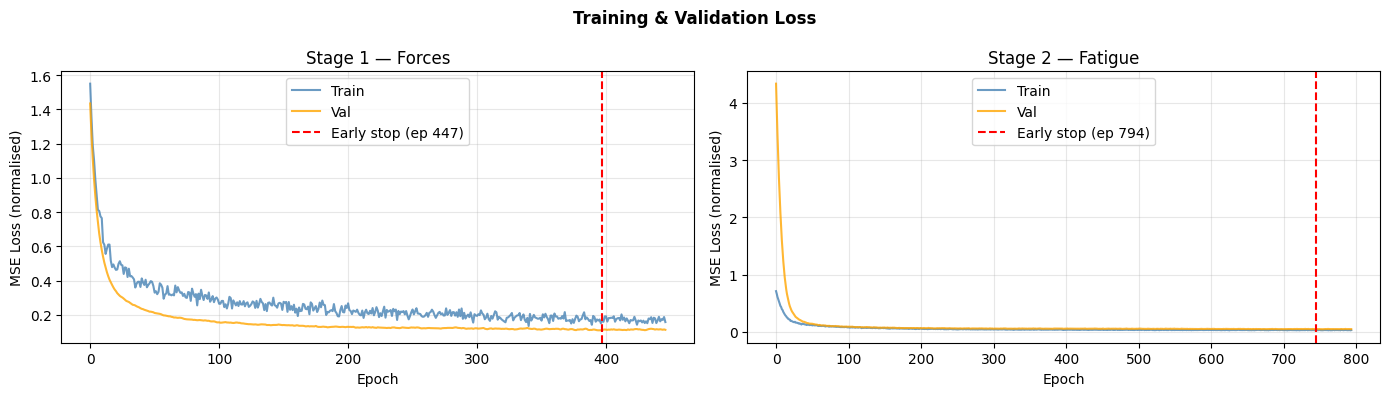

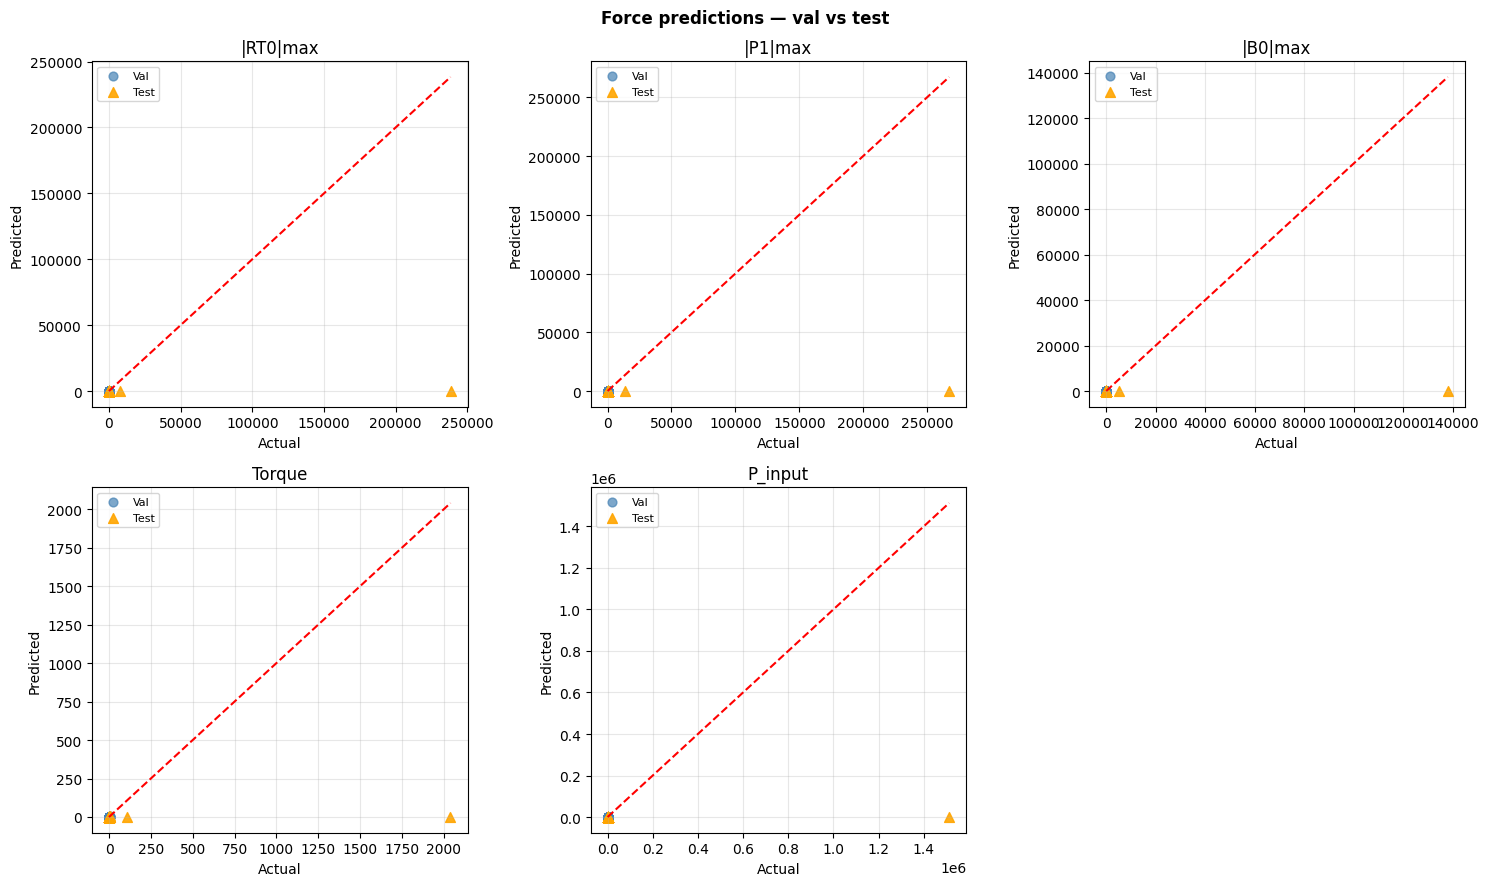

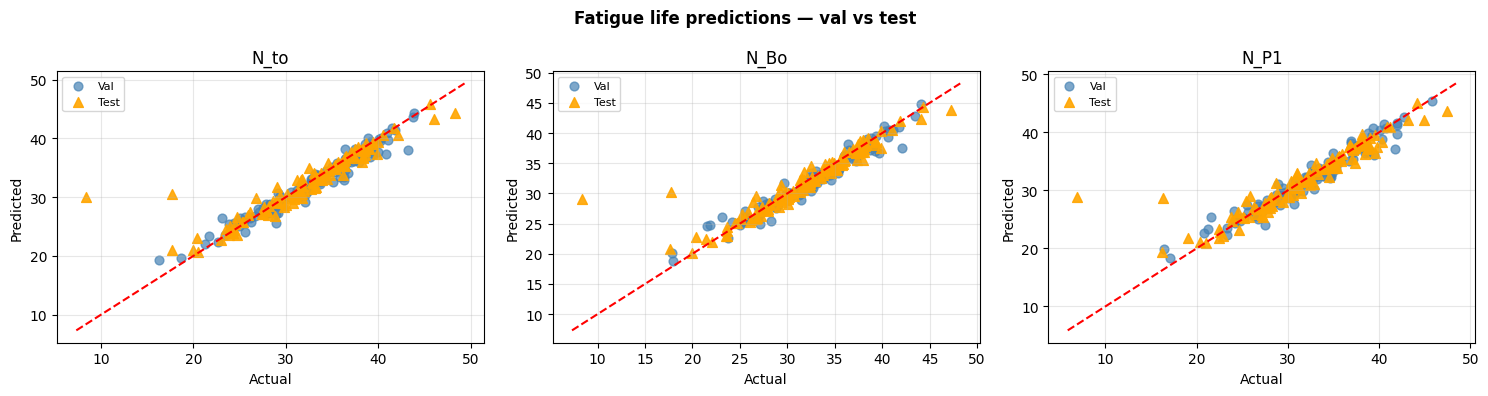

  Residuals
  -----------------------------------------------------------------
      Output |   Set |     Bias |      Std |  Max Err
  -----------------------------------------------------------------
  --- Forces ---
    |RT0|max |   Val |  +0.1146 |   1.4405 |   6.4845
    |RT0|max |  Test | -2047.7615 | 21663.8555 | 238256.4375
     |P1|max |   Val |  +0.3420 |   1.7337 |   9.9069
     |P1|max |  Test | -2339.1094 | 24317.0449 | 267272.5625
     |B0|max |   Val |  +0.1628 |   1.3792 |   6.0331
     |B0|max |  Test | -1193.6282 | 12553.1562 | 138035.2188
      Torque |   Val |  -0.0173 |   0.4571 |   3.7825
      Torque |  Test | -17.8938 | 185.5161 | 2039.0024
     P_input |   Val |  -0.4285 |   5.4006 |  55.1643
     P_input |  Test | -12623.5713 | 137522.5625 | 1512816.5000
  --- Fatigue ---
        N_to |   Val |  -0.4024 |   1.2631 |   5.1676
        N_to |  Test |  +0.0905 |   2.5795 |  21.7477
        N_Bo |   Val |  -0.3994 |   1.1506 |   4.6101
        N_Bo |  Test |  +0.10

In [69]:
# ── Loss curve ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training & Validation Loss', fontweight='bold')
for ax, train_h, val_h, stopped, title in [
    (axes[0], force_train_hist,   force_val_hist,   stopped_force,   'Stage 1 — Forces'),
    (axes[1], fatigue_train_hist, fatigue_val_hist, stopped_fatigue, 'Stage 2 — Fatigue'),
]:
    ax.plot(train_h, label='Train', color='steelblue', alpha=0.8)
    ax.plot(val_h,   label='Val',   color='orange',    alpha=0.8)
    ax.axvline(stopped - patience, color='red', linestyle='--', label=f'Early stop (ep {stopped})')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (normalised)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Force predictions scatter ──────────────────────────────────────────────────
n_f = len(force_cols)
fig, axes = plt.subplots(2, (n_f + 1) // 2, figsize=(5 * ((n_f + 1) // 2), 9))
fig.suptitle('Force predictions — val vs test', fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(force_cols):
    ax = axes[i]
    ax.scatter(tf_val_w[:, i], pf_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(tf_te_w[:,  i], pf_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(tf_val_w[:, i].min(), tf_te_w[:, i].min()) - 1
    hi = max(tf_val_w[:, i].max(), tf_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for ax in axes[n_f:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('force_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fatigue predictions scatter ────────────────────────────────────────────────
n_a = len(fatigue_cols)
fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 4))
fig.suptitle('Fatigue life predictions — val vs test', fontweight='bold')
for i, col in enumerate(fatigue_cols):
    ax = axes[i]
    ax.scatter(ta_val_w[:, i], pa_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(ta_te_w[:,  i], pa_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(ta_val_w[:, i].min(), ta_te_w[:, i].min()) - 1
    hi = max(ta_val_w[:, i].max(), ta_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fatigue_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Residual table ─────────────────────────────────────────────────────────────
print('  Residuals')
print('  ' + '-'*65)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-'*65)
for group_name, cols, pv, tv, pt, tt in [
    ('Forces',  force_cols,   pf_val_w, tf_val_w, pf_te_w, tf_te_w),
    ('Fatigue', fatigue_cols, pa_val_w, ta_val_w, pa_te_w, ta_te_w),
]:
    print(f'  --- {group_name} ---')
    for i, col in enumerate(cols):
        for label, yp, yt in [('Val', pv, tv), ('Test', pt, tt)]:
            err = yp[:, i] - yt[:, i]
            print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
                  f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-'*65)


In [70]:
print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')


      Output |   Val MAE |   Val R2 |  Test MAE |  Test R2
  ----------------------------------------------------------
    |RT0|max |    0.8790 |   0.3458 | 2048.5264 |  -0.0089
     |P1|max |    1.0009 |   0.0958 | 2340.1501 |  -0.0093
     |B0|max |    0.7976 |   0.1659 | 1194.4050 |  -0.0090
      Torque |    0.2026 |   0.6523 |   18.0264 |  -0.0095
     P_input |    1.3024 |   0.3310 | 12624.1553 |  -0.0084
